# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer

# ==========================================
# 2. LOAD & PREPROCESS DATA
# ==========================================

In [2]:
print("Loading data...")
df = pd.read_csv('clusteringmidterm.csv')

# Drop CUST_ID as it is not a behavioral feature
if 'CUST_ID' in df.columns:
    df_features = df.drop('CUST_ID', axis=1)
else:
    df_features = df.copy()

# Handle missing values (e.g., CREDIT_LIMIT and MINIMUM_PAYMENTS might have NaNs)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df_features), columns=df_features.columns)

# Scale data (K-Means is highly sensitive to variance and scale)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_imputed)

Loading data...


# ==========================================
# 3. FIND OPTIMAL K (ELBOW METHOD)
# ==========================================

Calculating Elbow Method...


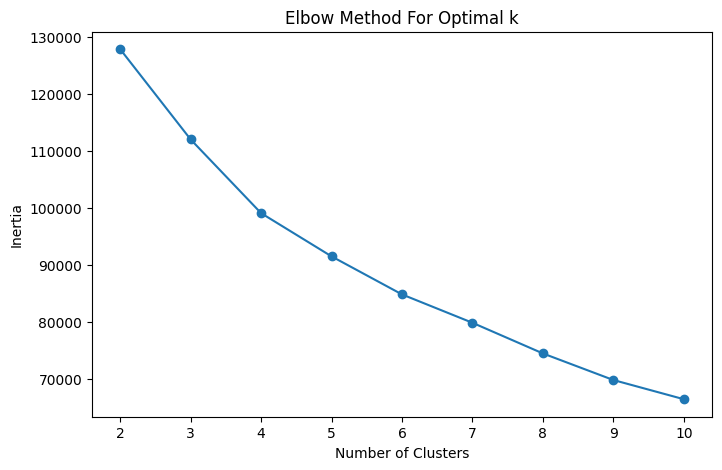

In [3]:
print("Calculating Elbow Method...")
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

# Plotting Elbow (In a real Jupyter notebook, this will display inline)
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

# ==========================================
# 4. APPLY K-MEANS
# ==========================================

In [4]:
optimal_k = 4 
print(f"\nApplying KMeans with k={optimal_k}...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)

# Add labels back to the original dataframe for interpretation
df['Cluster'] = cluster_labels

# Calculate Silhouette Score to evaluate cluster quality
sil_score = silhouette_score(df_scaled, cluster_labels)
print(f"Silhouette Score for k={optimal_k}: {sil_score:.4f}")


Applying KMeans with k=4...
Silhouette Score for k=4: 0.1977


# ==========================================
# 5. CLUSTER INTERPRETATION
# ==========================================

In [5]:
print("\n--- Cluster Centroids (Mean values per cluster) ---")
# Group by cluster and calculate mean to understand what each cluster represents
cluster_summary = df.drop('CUST_ID', axis=1, errors='ignore').groupby('Cluster').mean()
print(cluster_summary[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']])

# Example interpretation logic:
# Cluster 0 might be "Low Spenders"
# Cluster 1 might be "High Cash Advance Users"
# Cluster 2 might be "High Spenders / Full Payers"


--- Cluster Centroids (Mean values per cluster) ---
             BALANCE    PURCHASES  CASH_ADVANCE  CREDIT_LIMIT
Cluster                                                      
0        1012.658327   270.041785    596.509903   3278.710597
1        3551.153761  7681.620098    653.638891   9696.943765
2        4602.449658   501.862982   4521.509581   7546.160857
3         894.907458  1236.178934    210.570626   4213.207678


### **Conclusion: Cluster Interpretation**

Based on the mean values of the key features for each of the 4 clusters, we can profile the customer segments as follows:

*   **Cluster 0 - "Conservative/Low Spenders":** 
    This group has low balances (~1012), the lowest purchase volume (~270), and the lowest average credit limit (~3278). These customers likely use their cards infrequently for small, essential transactions or are inactive users.
*   **Cluster 1 - "High-Value Spenders":** 
    This group is characterized by extremely high purchase volumes (~7681) and the highest credit limits (~9696). While they maintain a relatively high balance (~3551), their primary behavior is heavy card usage for direct purchases rather than cash advances.
*   **Cluster 2 - "Cash Advance Reliant":** 
    This segment carries the highest average balance (~4602) but has very low direct purchases (~501). Instead, they have an extraordinarily high cash advance usage (~4521). These customers are utilizing the card primarily for short-term liquidity/cash loans.
*   **Cluster 3 - "Prudent/Everyday Spenders":** 
    This group maintains the lowest balance (~894) and almost zero cash advance usage (~210), but they have a healthy amount of direct purchases (~1236). This indicates responsible customers who use the card for regular expenses and likely pay off their balances quickly.